Fundamentals of Deep Learning Models

# Lab 05-3: LeNet for Image Classification
## Exercise: Image classification with a LeNet-style CNN

This exercise implements a **LeNet-style convolutional neural network** [LeCun98] using
the Keras Sequential API to classify CIFAR-10 images. The architecture follows the
classic pattern introduced in Section 5.1:
Conv(5×5) → Sigmoid → AvgPool(2×2) → Conv(5×5) → Sigmoid → AvgPool(2×2) → Flatten → Dense → Dense → Softmax.

Key components from the textbook:
- Convolutional layers (Section 5.3, Eq. 5.4)
- Average pooling (Section 5.4, Eq. 5.11)
- Flatten layer (Section 5.5)
- Xavier (Glorot) initialization (Section 4.4)
- Adam optimizer (Section 4.3)

### Prepare dataset

CIFAR-10 contains 60,000 color images (32×32×3) in 10 classes.
Source: https://www.cs.toronto.edu/~kriz/cifar.html (public research dataset).

In [1]:
import numpy as np
import tensorflow as tf
import tensorflow.keras as keras
import matplotlib.pyplot as plt

print('NumPy version:', np.__version__)
print('TensorFlow version:', tf.__version__)
print('Keras version:', keras.__version__)
print('Matplotlib version:', plt.matplotlib.__version__)

NumPy version: 2.0.2
TensorFlow version: 2.19.0
Keras version: 3.13.2
Matplotlib version: 3.10.0


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step


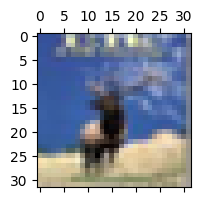

The picture is deer
Train dataset dimensions:  (40000, 32, 32, 3) (40000, 10)


In [2]:
# Load the original CIFAR10 dataset
# CIFAR10 dataset contains 50000 training images and 10000 test images of 32x32x3 pixels
# Each image contains a small object such as bird, truck, etc...
(X_train_org, y_train_num), (X_test_org, y_test) = keras.datasets.cifar10.load_data()

# Digits data has range of [0,255], which often lead too big exponential values
# so make them normal distribution of [0,1] with the sklearn package, or you can just divide them by 255
X_train = X_train_org / 255
X_test = X_test_org / 255

# Transform Nx1 Y vector to Nx10 answer vector, so that we can perform one-to-all classification
y_train = tf.reshape(tf.one_hot(y_train_num, 10), [-1,10])
#y_test_N = tf.reshape(tf.one_hot(y_test, 10), [-1,10])

# Split training dataset into training and validation
X_val = X_train[40000:50000]
y_val = y_train[40000:50000]

X_train = X_train[:40000]
y_train = y_train[:40000]

# CIFAR10 labels: airplane(0), automobile(1), bird(2), cat(3), deer(4), dog(5), frog(6), horse(7), ship(8), truck(9)
cls_names = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

n_channels = 3
n_classes = 10

idx = np.random.randint(X_test.shape[0])
plt.figure(figsize=(2,2))
plt.matshow(X_test_org[idx], 0)
plt.show()
print('The picture is', cls_names[y_test[idx].item()])

print('Train dataset dimensions: ', X_train.shape, y_train.shape)

### Network definition with Keras Sequential API

This exercise constructs a LeNet-style model (Section 5.1, [LeCun98]) using `keras.Sequential`.
The original LeNet-5 used sigmoid activations and average pooling, which are preserved here.
An alternative method is to create an empty model and then add layers one by one.

In [ ]:
# model
model = keras.Sequential([

    ### START CODE HERE ###

    # Input layer: 32x32 RGB images
    keras.layers.InputLayer(),
    # Layer 1: Conv2D with 6 filters of 5x5 (Section 5.3, Eq. 5.4)
    keras.layers.Conv2D(),  # Xavier init (Section 4.4)
    # Average pooling 2x2 to reduce spatial size by half (Section 5.4, Eq. 5.11)
    keras.layers....
    # Layer 2: Conv2D with 16 filters of 5x5, valid padding reduces spatial size
    keras.layers....
    # Average pooling 2x2
    keras.layers....
    # Flatten 3D feature maps to 1D vector (Section 5.5)
    keras.layers.Flatten(),
    # Layer 3: Fully connected, 120 units (Section 3.2)
    keras.layers....
    # Layer 4: Fully connected, 84 units
    keras.layers....
    # Layer 5: Output layer with softmax for 10-class classification (Section 3.4, Eq. 3.13)
    keras.layers....

    ### END CODE HERE ###

])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 6)      │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 16, 16, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 12, 12, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 6, 6, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        69,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 83,126 (324.71 KB)

 Trainable params: 83,126 (324.71 KB)

 Non-trainable params: 0 (0.00 B)

### Training model and showing history

In [4]:
# Compile with Adam optimizer (Section 4.3) and categorical cross-entropy loss (Eq. 3.16)
opt = keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['acc'])

# Train with mini-batch gradient descent (Section 4.2), shuffle enabled
history = model.fit(X_train, y_train, batch_size=64, epochs=30,
                    validation_data=[X_val, y_val], verbose=2, shuffle=True)

Epoch 1/30
625/625 - 9s - 14ms/step - acc: 0.2007 - loss: 2.1178 - val_acc: 0.2561 - val_loss: 2.0113
Epoch 2/30
625/625 - 2s - 4ms/step - acc: 0.2806 - loss: 1.9390 - val_acc: 0.3128 - val_loss: 1.8858
Epoch 3/30
625/625 - 3s - 4ms/step - acc: 0.3438 - loss: 1.8094 - val_acc: 0.3675 - val_loss: 1.7536
Epoch 4/30
625/625 - 3s - 4ms/step - acc: 0.3850 - loss: 1.7073 - val_acc: 0.3966 - val_loss: 1.6938
Epoch 5/30
625/625 - 3s - 4ms/step - acc: 0.4125 - loss: 1.6370 - val_acc: 0.4248 - val_loss: 1.6131
Epoch 6/30
625/625 - 2s - 4ms/step - acc: 0.4282 - loss: 1.5843 - val_acc: 0.4271 - val_loss: 1.5832
Epoch 7/30
625/625 - 2s - 4ms/step - acc: 0.4440 - loss: 1.5449 - val_acc: 0.4434 - val_loss: 1.5397
Epoch 8/30
625/625 - 3s - 5ms/step - acc: 0.4546 - loss: 1.5148 - val_acc: 0.4528 - val_loss: 1.5133
Epoch 9/30
625/625 - 3s - 4ms/step - acc: 0.4670 - loss: 1.4857 - val_acc: 0.4577 - val_loss: 1.5088
Epoch 10/30
625/625 - 2s - 4ms/step - acc: 0.4738 - loss: 1.4595 - val_acc: 0.4612 - val_l

### Evaluate model

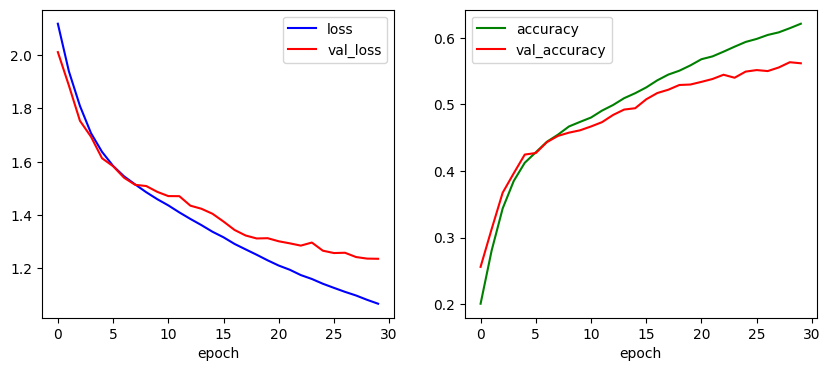

In [5]:
# plot loss and accuracy
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], 'b-', label='loss')
plt.plot(history.history['val_loss'], 'r-', label='val_loss')
plt.xlabel('epoch')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['acc'], 'g-', label='accuracy')
plt.plot(history.history['val_acc'], 'r-', label='val_accuracy')
plt.xlabel('epoch')
plt.legend()

plt.show()

In [6]:
from sklearn.metrics import accuracy_score

y_prob = model.predict(X_test)
y_pred = tf.math.argmax(y_prob, axis=1)

print(y_test[0:10].reshape(-1))
print(y_pred[0:10].numpy())

accuracy_score(y_pred, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
[3 8 8 0 6 6 1 6 3 1]
[3 0 1 0 4 3 1 6 5 1]


0.5588

### Test model with a random sample

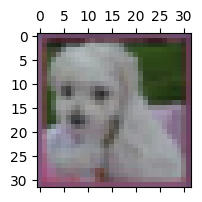

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
My prediction is dog
Actual image is  dog


In [8]:
idx = np.random.randint(X_test.shape[0])
plt.figure(figsize=(2,2))
plt.matshow(X_test_org[idx], 0)
plt.show()

X_in = tf.expand_dims(X_test[idx], 0)

y_prob = model.predict(X_in)
y_pred = np.argmax(y_prob, axis=1)

print('My prediction is ' + cls_names[y_pred[0]])
print('Actual image is  ' + cls_names[y_test[idx].item()])

(c) 2026 S. W. Lee